# 03 Feature Engineering

Validacion del contrato final de features y del preprocesador reusable definido en `src/features/build_features.py`, partiendo de una muestra candidata que ya paso por las reglas estructurales de cleaning. En esta etapa la pregunta ya no es que filas descartar, sino que columnas seguras y derivadas deterministicas deben sobrevivir hasta modelado y serving.

## Objetivo del notebook

Este notebook documenta que el modelo trabaja con un conjunto **pequeno, interpretable, multi-flota y libre de leakage**, y que cualquier transformacion adicional se aplica dentro de un pipeline reproducible alineado con la OBT y la API.

## Secuencia metodologica

1. tomar una muestra candidata ya filtrada por reglas estructurales
2. separar de forma explicita las columnas diagnosticas de las columnas aptas para modelado
3. construir el frame final de features seguras
4. verificar derivadas temporales, variables categoricas y preprocesamiento reusable

## Decision de diseno

En esta fase no se agregan features complejas que puedan introducir leakage o depender de fuentes externas no estabilizadas. Se privilegia un contrato claro y defendible frente a la rubrica: features simples, seguras, compatibles con `yellow` y `green`, y consistentes con serving.

La frontera metodologica es explicita: las derivadas documentadas aqui son deterministicas y no aprenden parametros desde `validation` o `test`. Si mas adelante se incorpora alguna transformacion ajustada, su fitting debe hacerse exclusivamente sobre `train`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import balanced_raw_sample_sql, fetch_sample
from src.features.build_features import CATEGORICAL_FEATURES, DISTANCE_COLUMN, MODEL_FEATURE_COLUMNS, NUMERIC_FEATURES, RAW_FEATURE_COLUMNS, TARGET_COLUMN, build_candidate_modeling_frame, get_feature_pipeline, prepare_feature_frame, split_features_target
from src.utils.config import get_settings

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
settings = get_settings()
raw_feature_sample = fetch_sample(
    balanced_raw_sample_sql(settings, limit=8000, sample_seed=settings.eda_sample_seed),
    limit=8000,
    sample_seed=settings.eda_sample_seed,
    settings=settings,
)
feature_df = build_candidate_modeling_frame(
    raw_feature_sample,
    start_date=settings.data_start_date,
    end_date=settings.data_end_date,
)
modeling_df = feature_df.loc[:, RAW_FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
assert not feature_df.empty, 'La muestra candidata de features esta vacia.'
print('raw feature sample shape =', raw_feature_sample.shape)
print('candidate feature sample shape =', feature_df.shape)
print('modeling feature sample shape =', modeling_df.shape)
print('sample by trip_type =')
print(modeling_df['trip_type'].value_counts(dropna=False).sort_index())
print('candidate columns =', feature_df.columns.tolist())
print('modeling columns =', modeling_df.columns.tolist())
modeling_df.head()


raw feature sample shape = (8000, 19)
candidate feature sample shape = (6448, 20)
modeling feature sample shape = (6448, 9)
sample by trip_type =
trip_type
green     3474
yellow    2974
Name: count, dtype: int64
candidate columns = ['trip_type', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'pickup_location_id', 'dropoff_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'estimated_distance']
modeling columns = ['pickup_datetime', 'passenger_count', 'estimated_distance', 'pickup_location_id', 'dropoff_location_id', 'vendor_id', 'ratecode_id', 'trip_type', 'fare_amount']


,pickup_datetime,passenger_count,estimated_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id,trip_type,fare_amount
0,2025-06-03 16:09:39,1.0,1.70,130,130,2,1.0,green,19.1
1,2025-04-28 20:10:05,1.0,2.90,163,79,1,1.0,yellow,17.7
4,2025-04-21 17:14:02,1.0,1.60,244,243,1,1.0,green,19.1
6,2025-03-30 21:35:48,1.0,1.90,97,256,2,1.0,green,13.5
7,2025-01-02 18:04:57,1.0,0.86,95,95,2,1.0,green,7.2


In [3]:
X_raw, y = split_features_target(modeling_df)
X_prepared = prepare_feature_frame(X_raw)
print('raw feature frame =', X_raw.shape)
print('prepared feature frame =', X_prepared.shape)
X_prepared.head()


raw feature frame = (6448, 8)
prepared feature frame = (6448, 16)


,trip_type,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,passenger_count,estimated_distance,log_estimated_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id,route_id,same_zone
0,green,16,1,6,0,1,0,1.0,1.70,0.993252,130,130,2,1.0,130_130,1
1,yellow,20,0,4,0,0,0,1.0,2.90,1.360977,163,79,1,1.0,163_79,0
4,green,17,0,4,0,1,0,1.0,1.60,0.955511,244,243,1,1.0,244_243,0
6,green,21,6,3,1,0,0,1.0,1.90,1.064711,97,256,2,1.0,97_256,0
7,green,18,3,1,0,1,0,1.0,0.86,0.620576,95,95,2,1.0,95_95,1


In [4]:
missing_model_cols = sorted(set(MODEL_FEATURE_COLUMNS).difference(X_prepared.columns))
assert not missing_model_cols, f'Faltan columnas de modelado: {missing_model_cols}'
role_map = {
    'trip_type': 'categorical fleet',
    'pickup_hour': 'numeric temporal',
    'pickup_dayofweek': 'numeric temporal',
    'pickup_month': 'numeric temporal',
    'is_weekend': 'numeric temporal',
    'is_rush_hour': 'numeric temporal',
    'is_night': 'numeric temporal',
    'passenger_count': 'numeric trip',
    DISTANCE_COLUMN: 'numeric trip',
    'log_estimated_distance': 'numeric trip',
    'route_id': 'categorical route',
    'same_zone': 'categorical route',
    'pickup_location_id': 'categorical location',
    'dropoff_location_id': 'categorical location',
    'vendor_id': 'categorical operator',
    'ratecode_id': 'categorical operator',
}
feature_contract = pd.DataFrame({
    'feature': MODEL_FEATURE_COLUMNS,
    'role': [role_map[name] for name in MODEL_FEATURE_COLUMNS],
})
feature_contract


,feature,role
0,trip_type,categorical fleet
1,pickup_hour,numeric temporal
2,pickup_dayofweek,numeric temporal
3,pickup_month,numeric temporal
4,is_weekend,numeric temporal
5,is_rush_hour,numeric temporal
6,is_night,numeric temporal
7,passenger_count,numeric trip
8,estimated_distance,numeric trip
9,log_estimated_distance,numeric trip


In [5]:
X_prepared[NUMERIC_FEATURES].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
pickup_hour,6448.0,14.138337,5.440352,0.0,0.0,3.0,15.0,22.0,23.0,23.0
pickup_dayofweek,6448.0,2.948666,1.912788,0.0,0.0,0.0,3.0,6.0,6.0,6.0
pickup_month,6448.0,3.513027,1.682717,1.0,1.0,1.0,4.0,6.0,6.0,6.0
is_weekend,6448.0,0.254342,0.435525,0.0,0.0,0.0,0.0,1.0,1.0,1.0
is_rush_hour,6448.0,0.412376,0.4923,0.0,0.0,0.0,0.0,1.0,1.0,1.0
is_night,6448.0,0.131203,0.337649,0.0,0.0,0.0,0.0,1.0,1.0,1.0
passenger_count,6448.0,1.305831,0.829959,1.0,1.0,1.0,1.0,3.0,5.0,6.0
estimated_distance,6448.0,3.015164,3.672949,0.01,0.2,0.55,1.8,10.0965,18.4453,55.63
log_estimated_distance,6448.0,1.164736,0.600704,0.00995,0.182322,0.438255,1.029619,2.40663,2.967605,4.036539
same_zone,6448.0,0.074907,0.263262,0.0,0.0,0.0,0.0,1.0,1.0,1.0


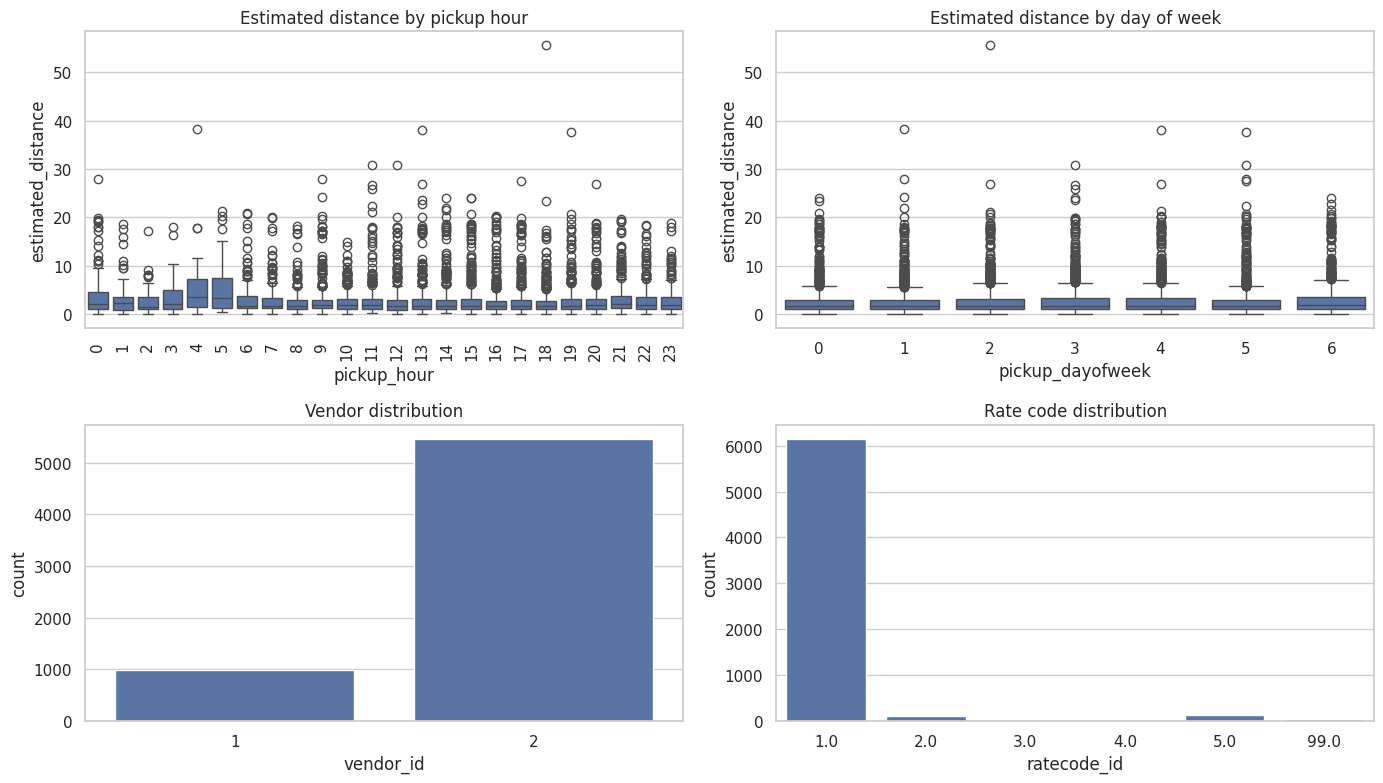

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=X_prepared, x='pickup_hour', y=DISTANCE_COLUMN, ax=axes[0, 0])
axes[0, 0].set_title('Estimated distance by pickup hour')
axes[0, 0].tick_params(axis='x', rotation=90)
sns.boxplot(data=X_prepared, x='pickup_dayofweek', y=DISTANCE_COLUMN, ax=axes[0, 1])
axes[0, 1].set_title('Estimated distance by day of week')
sns.countplot(data=X_prepared, x='vendor_id', ax=axes[1, 0])
axes[1, 0].set_title('Vendor distribution')
sns.countplot(data=X_prepared, x='ratecode_id', ax=axes[1, 1])
axes[1, 1].set_title('Rate code distribution')
plt.tight_layout()


In [7]:
pipeline = get_feature_pipeline()
X_transformed = pipeline.fit_transform(X_raw, y)
print('numeric features =', NUMERIC_FEATURES)
print('categorical features =', CATEGORICAL_FEATURES)
print('transformed shape =', X_transformed.shape)


numeric features = ['pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour', 'is_night', 'passenger_count', 'estimated_distance', 'log_estimated_distance', 'same_zone']
categorical features = ['trip_type', 'pickup_location_id', 'dropoff_location_id', 'vendor_id', 'ratecode_id', 'route_id']
transformed shape = (6448, 2742)


In [8]:
pd.Series(y).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


count    6448.000000
mean       18.021607
std        15.769264
min         0.300000
1%          4.400000
5%          5.800000
50%        13.500000
95%        47.800000
99%        75.000000
max       266.200000
Name: fare_amount, dtype: float64

## Conclusiones e interpretacion

- La muestra candidata de cleaning (`6448` filas en esta corrida) no puede pasar directamente a modelado porque todavia conserva columnas diagnosticas y de leakage. La separacion explicita hacia `modeling_df` confirma la frontera correcta entre cleaning estructural y contrato final de features.
- El contrato final ya queda claramente definido: `trip_type`, `estimated_distance`, zonas, `vendor_id`, `ratecode_id`, `pickup_datetime` y derivadas temporales deterministicas. En esta corrida el frame preparado termina con `16` features semanticas antes del encoding, lo que mantiene interpretabilidad sin perder informacion relevante.
- La integracion multi-flota queda defendida: despues del cleaning la muestra sigue incluyendo ambas flotas (`3474` green y `2974` yellow), por lo que `trip_type` debe preservarse como feature categorica real y no solo como detalle operativo de ingesta.
- El preprocesador reusable queda justificado como una sola fuente de verdad para entrenamiento e inferencia. El espacio transformado de `2742` columnas refleja principalmente el one-hot encoding de ubicaciones, rutas y categorias, no leakage adicional.
- Con este notebook ya queda estable la base de features para pasar a experimentacion sobre la OBT materializada. Cualquier cambio futuro en features debe reflejarse simultaneamente en `build_features.py`, en el SQL de la OBT y en la API.
